In [ ]:
Customer Buying Behaviour Analysis using RFM and Visualization


In [2]:
#IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#LOAD DATASET
df = pd.read_excel("E:/r code/pbl 3 data set rfm analysis R/Online Retail.xlsx")
df.head()

In [ ]:
#DATA UNDERSTANDING
df.info()
df.describe()

In [12]:
#DATA CLEANING
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [13]:
df = df.sample(5000, random_state=123)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
139504,548325,21094,SET/6 RED SPOTTY PAPER PLATES,24,2011-03-30 13:01:00,0.85,13509.0,United Kingdom,20.40
472684,576695,21905,MORE BUTTER METAL SIGN,1,2011-11-16 12:25:00,0.79,16469.0,United Kingdom,0.79
404239,571670,21891,TRADITIONAL WOODEN SKIPPING ROPE,12,2011-10-18 13:12:00,1.45,12611.0,Italy,17.40
370665,569148,21912,VINTAGE SNAKES & LADDERS,4,2011-09-30 15:52:00,3.75,16613.0,United Kingdom,15.00
165360,550784,21137,BLACK RECORD COVER FRAME,8,2011-04-20 13:59:00,3.75,13269.0,United Kingdom,30.00


In [14]:
#RFM calculation
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,183,3,66.30
12349.0,19,1,12.50
12350.0,310,1,19.80
12356.0,326,1,75.00
12357.0,33,3,64.56


In [11]:
# RFM Scoring (1–5 scale)

rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Combine scores
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12347.0,183,3,66.30,2,4,5,245
12349.0,19,1,12.50,5,1,2,512
12350.0,310,1,19.80,1,1,3,113
12356.0,326,1,75.00,1,1,5,115
12357.0,33,3,64.56,4,4,5,445


In [17]:
# Segmentation

rfm['Segment'] = 'Regular'

rfm.loc[rfm['RFM_Score'] >= '444', 'Segment'] = 'High Value'
rfm.loc[rfm['RFM_Score'] <= '222', 'Segment'] = 'Low Value'

rfm[['Recency','Frequency','Monetary','RFM_Score','Segment']].head()

,Recency,Frequency,Monetary,RFM_Score,Segment
CustomerID,,,,,
12347.0,183,3,66.30,245,Regular
12349.0,19,1,12.50,512,High Value
12350.0,310,1,19.80,113,Low Value
12356.0,326,1,75.00,115,Low Value
12357.0,33,3,64.56,445,High Value


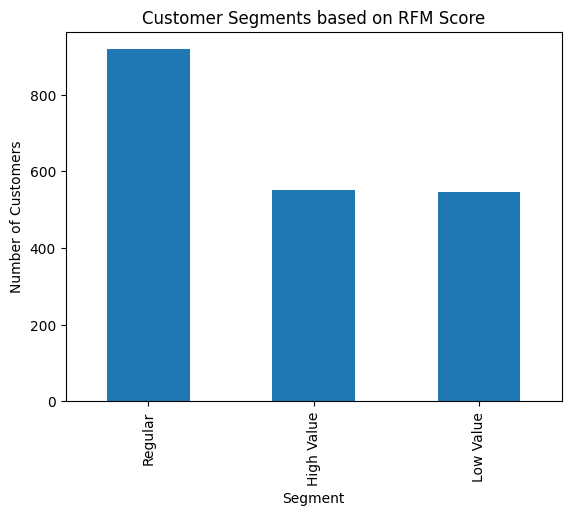

In [18]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments based on RFM Score")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
#VISUALIZATION 

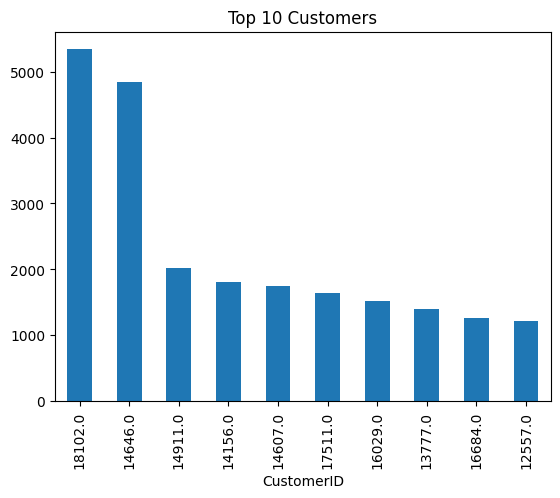

In [15]:
#BAR chart
rfm.sort_values('Monetary', ascending=False).head(10)['Monetary'].plot(kind='bar')
plt.title("Top 10 Customers")
plt.show()

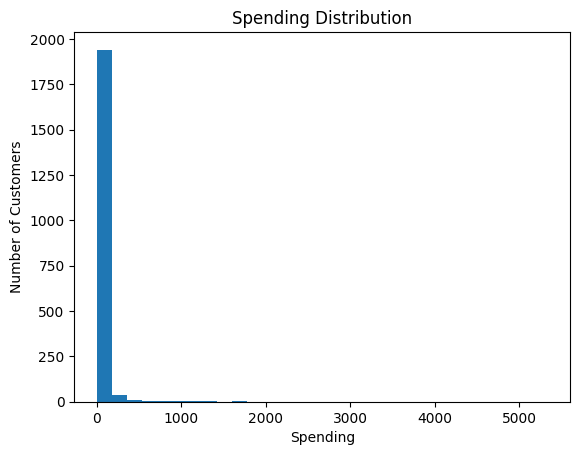

In [37]:
#histogram
plt.hist(rfm['Monetary'], bins=30)
plt.title("Spending Distribution")
plt.xlabel("Spending")
plt.ylabel("Number of Customers")
plt.show()

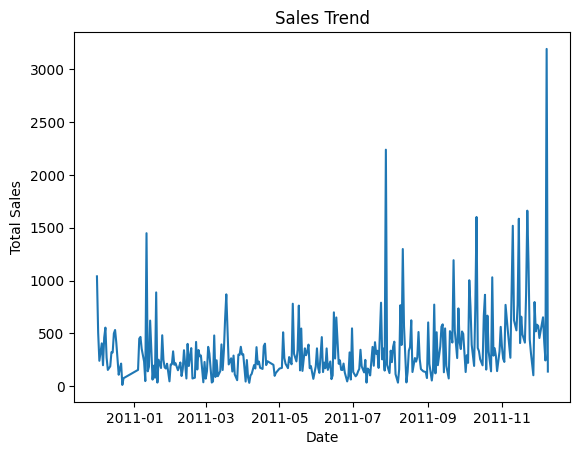

In [38]:
#line chart
sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

sales.plot()
plt.title("Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

In [34]:
#clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=3, random_state=123)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

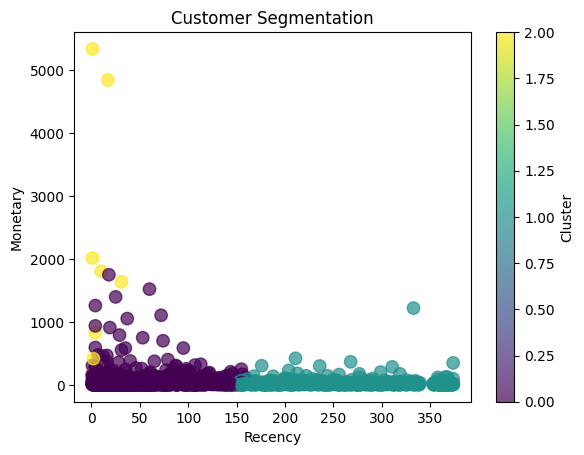

In [39]:
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis', s=80, alpha=0.7)

plt.title("Customer Segmentation")
plt.xlabel("Recency")
plt.ylabel("Monetary")

# Add color bar (important)
plt.colorbar(label='Cluster')

plt.show()

In [31]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,53.070370,2.691111,52.693015
1,253.270642,1.484709,29.180061
2,8.111111,44.000000,1929.121111


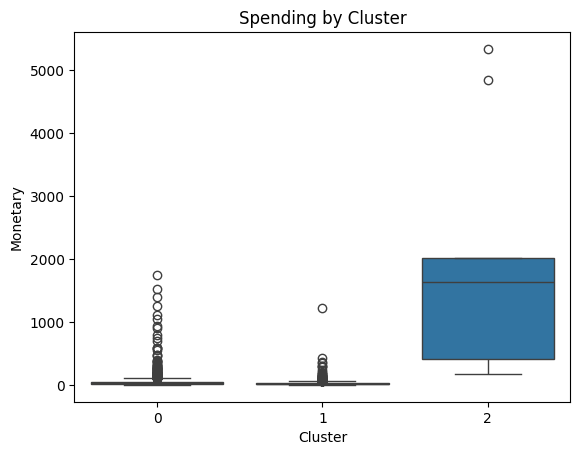

In [32]:
#box plot
import seaborn as sns

sns.boxplot(x=rfm['Cluster'], y=rfm['Monetary'])
plt.title("Spending by Cluster")
plt.show()

In [40]:
#LASSIFICATION USING DECISION TREE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Features and Target
X = rfm[['Recency','Frequency','Monetary']]
y = rfm['Cluster']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9925558312655087


In [35]:
print("""
Summary:
- Customer purchase data was cleaned by removing missing CustomerID and invalid transactions.
- A sample of 5000 records was used for efficient analysis.
- RFM (Recency, Frequency, Monetary) metrics were calculated to understand customer behavior.
- Most customers have low purchase frequency and low spending.
- A small group of customers contributes significantly to total revenue.
- Spending distribution is highly skewed, with few high-value customers.
- Sales trend shows fluctuations over time, indicating varying demand patterns.
- K-Means clustering grouped customers into 3 segments based on behavior.
- One cluster represents high-value customers (frequent and high spenders).
- Another cluster represents low-value or inactive customers.
- The remaining cluster represents regular or moderate customers.
- This segmentation helps businesses target customers effectively and improve marketing strategies.
""")


Summary:
- Customer purchase data was cleaned by removing missing CustomerID and invalid transactions.
- A sample of 5000 records was used for efficient analysis.
- RFM (Recency, Frequency, Monetary) metrics were calculated to understand customer behavior.
- Most customers have low purchase frequency and low spending.
- A small group of customers contributes significantly to total revenue.
- Spending distribution is highly skewed, with few high-value customers.
- Sales trend shows fluctuations over time, indicating varying demand patterns.
- K-Means clustering grouped customers into 3 segments based on behavior.
- One cluster represents high-value customers (frequent and high spenders).
- Another cluster represents low-value or inactive customers.
- The remaining cluster represents regular or moderate customers.
- This segmentation helps businesses target customers effectively and improve marketing strategies.

